Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

Dataset cleaning

In [2]:
train = pd.read_csv('C:/Users/iahas/OneDrive/Documents/New ML projects/COMP 6721/CUSTOMER RETENTION STRATEGIES IN E-COMMERCE/Train_Data.csv')
test  = pd.read_csv('C:/Users/iahas/OneDrive/Documents/New ML projects/COMP 6721/CUSTOMER RETENTION STRATEGIES IN E-COMMERCE/Test_Data.csv')

print('Raw shapes:', train.shape, test.shape)

print('\nStarting the dataset cleaning:')
# Checking for any missing values across all features in the training set
print('\nMissing values found in the training dataset:')
print(train.isnull().sum())

# We will impute missing numerical values using the median to ensure data consistency
num_cols = ['esent', 'eopenrate', 'eclickrate', 'avgorder', 'ordfreq']
for col in num_cols:
    median_val = train[col].median()
    train[col] = train[col].fillna(median_val)
    test[col]  = test[col].fillna(median_val)

# Dropping the rows that are still missing dates
train = train.dropna(subset=['created', 'firstorder', 'lastorder'])
test  = test.dropna(subset=['created', 'firstorder', 'lastorder'])

# We will use the built in datetime found in pandas as it is easier to work with
date_cols = ['created', 'firstorder', 'lastorder']
for col in date_cols:
    train[col] = pd.to_datetime(train[col], dayfirst=True, format='mixed', errors='coerce')
    test[col]  = pd.to_datetime(test[col],  dayfirst=True, format='mixed', errors='coerce')

# We will identify any dates that failed to parse and were converted to NaT, and remove the collums
print('Unparseable dates turned into NaT:')
for col in date_cols:
    print(f'  train[{col}]: {train[col].isna().sum()} | test[{col}]: {test[col].isna().sum()}')
train = train.dropna(subset=date_cols)
test  = test.dropna(subset=date_cols)
print(f'\nShapes after dropping bad dates: train={train.shape}, test={test.shape}')

# Establishing a reference point to calculate the recency of customer activity
reference_date = train['lastorder'].max()

# We will engineer new features representing customer tenure and time since last purchase
for df in [train, test]:
    df['tenure_days']     = (df['lastorder']  - df['created']).dt.days
    df['days_to_first']   = (df['firstorder'] - df['created']).dt.days
    df['days_since_last'] = (reference_date   - df['lastorder']).dt.days

# Dropping the collumns the models do not need, we get:
drop_cols = ['custid', 'created', 'firstorder', 'lastorder']
train = train.drop(columns=drop_cols)
test  = test.drop(columns=drop_cols)

# Reviewing the statistical distribution of our cleaned features
print('\nStatistical distribution of our cleaned features')
print(train.describe().round(2))

print('\nFinal columns')
print(train.columns.tolist())
print('\nCleaning complete. Shapes:', train.shape, test.shape)

Raw shapes: (30801, 15) (38, 14)

Starting the dataset cleaning:

Missing values found in the training dataset:
custid        20
retained       0
created       20
firstorder    20
lastorder     20
esent          0
eopenrate      0
eclickrate     0
avgorder       0
ordfreq        0
paperless      0
refill         0
doorstep       0
favday         0
city           0
dtype: int64
Unparseable dates turned into NaT:
  train[created]: 0 | test[created]: 0
  train[firstorder]: 12 | test[firstorder]: 0
  train[lastorder]: 23 | test[lastorder]: 0

Shapes after dropping bad dates: train=(30758, 15), test=(38, 14)

Statistical distribution of our cleaned features
       retained     esent  eopenrate  eclickrate  avgorder   ordfreq  \
count  30758.00  30758.00   30758.00    30758.00  30758.00  30758.00   
mean       0.79     28.14      25.56        5.67     61.85      0.04   
std        0.40     16.75      29.56       10.57     40.95      0.10   
min        0.00      0.00       0.00        0.00   

Data Preprocessing (Cannot rerun only cell, rerun all when needed)

In [3]:
# We will encode the categorical columns favday and city into a separate 0/1 column for each unique value found
train = pd.get_dummies(train, columns=['favday', 'city'], drop_first=True)
test  = pd.get_dummies(test,  columns=['favday', 'city'], drop_first=True)

# We will align the columns so that test has the exact same structure as train so that if a city or day appears in train but not in test, test gets a 0 column for it
train, test = train.align(test, join='left', axis=1, fill_value=0)

print('Shape after encoding:', train.shape, test.shape)

# Separating our features from the target variable
TARGET   = 'retained'
FEATURES = [col for col in train.columns if col != TARGET]

X = train[FEATURES]
y = train[TARGET]

# Test set has no real labels so we only used for final predictions only
X_test_final = test[FEATURES]

print(f'\nFeatures used ({len(FEATURES)}):')
print(FEATURES)

# Test set has no labels so we carve out a validation set from training data to use for model evaluation instead
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTraining samples   : {X_train.shape[0]}')
print(f'Validation samples : {X_val.shape[0]}')

# We will fit the scaler on training data only & apply the same scale to both validation and test to prevent data leakage
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test_final)

print(f'\nPreprocessing complete.')
print(f'   X_train : {X_train_scaled.shape}')
print(f'   X_val   : {X_val_scaled.shape}')
print(f'   X_test  : {X_test_scaled.shape}')
print(f'   Retention rate — train: {y_train.mean():.1%} | val: {y_val.mean():.1%}')

Shape after encoding: (30758, 21) (38, 21)

Features used (20):
['esent', 'eopenrate', 'eclickrate', 'avgorder', 'ordfreq', 'paperless', 'refill', 'doorstep', 'tenure_days', 'days_to_first', 'days_since_last', 'favday_Monday', 'favday_Saturday', 'favday_Sunday', 'favday_Thursday', 'favday_Tuesday', 'favday_Wednesday', 'city_BOM', 'city_DEL', 'city_MAA']

Training samples   : 24606
Validation samples : 6152

Preprocessing complete.
   X_train : (24606, 20)
   X_val   : (6152, 20)
   X_test  : (38, 20)
   Retention rate — train: 79.5% | val: 79.5%


K-Means Clustering: Plot elbow curve

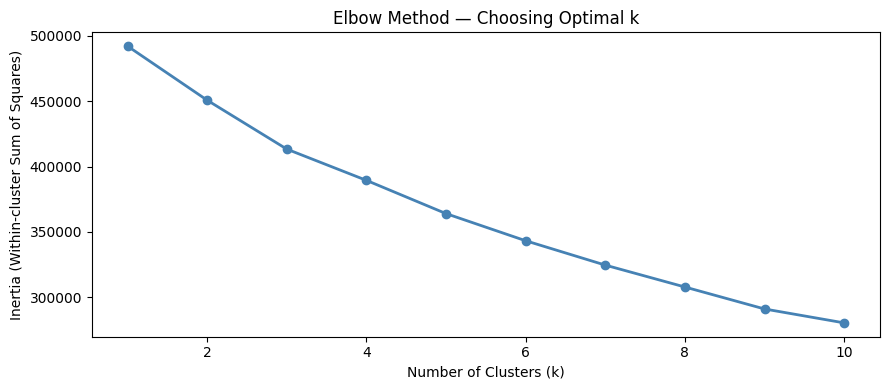

Observation: Inspect the curve above and identify where it bends.
That bend point is the optimal k value we will use below.


In [4]:
# We will use the elbow method to identify the optimal number of clusters by measuring how much variance is explained as we increase k
inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_scaled)
    inertia.append(km.inertia_)

# Plotting the elbow curve to visually identify where adding more clusters stops providing meaningful improvement
plt.figure(figsize=(9, 4))
plt.plot(K_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.title('Elbow Method — Choosing Optimal k')
plt.tight_layout()
plt.show()

print('Observation: Inspect the curve above and identify where it bends.')
print('That bend point is the optimal k value we will use below.')

K-Means Clustering: Decide number of clusters

In [5]:
# We will set k based on the elbow plot above — adjust this value if needed
K = 3

# Fitting the final K-Means model on our scaled training data
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
X_train_clusters = kmeans.fit_predict(X_train_scaled)
X_val_clusters   = kmeans.predict(X_val_scaled)

# Adding the cluster labels back to a copy of the training data for analysis
train_clustered = X_train.copy()
train_clustered['cluster']  = X_train_clusters
train_clustered['retained'] = y_train.values

print(f'K-Means fitted with k={K}')
print('\nCluster distribution:')
print(train_clustered['cluster'].value_counts().sort_index())

K-Means fitted with k=3

Cluster distribution:
cluster
0    7038
1    9827
2    7741
Name: count, dtype: int64


K value chosen = 3, as 4 gave us a cluster of 900 and another of 9000 -> uneven split, while 3 gives a very even split

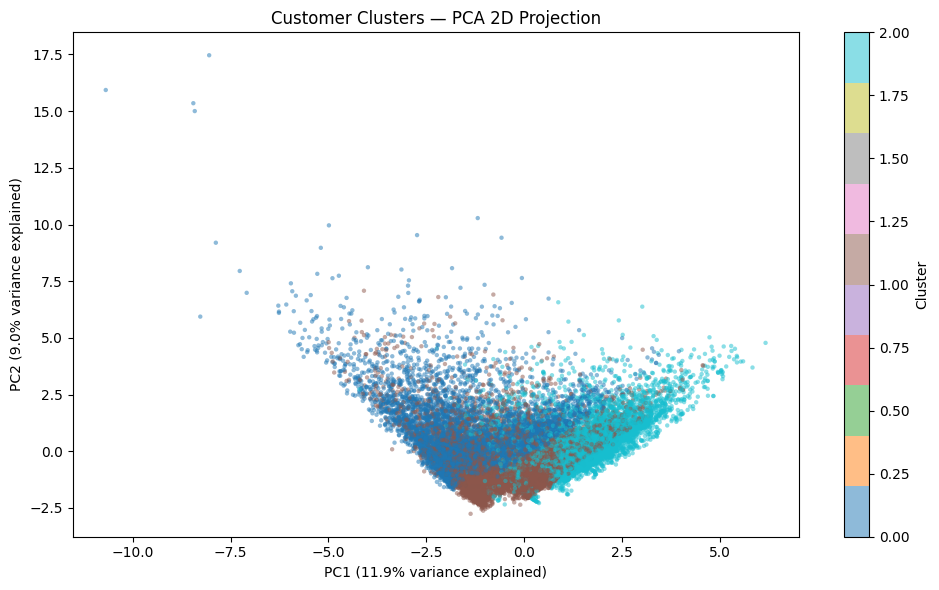

In [ ]:

# Reducing our 20 features down to 2 dimensions using PCA to plot human readable clusters
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_train_scaled)
explained = pca.explained_variance_ratio_

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    coords[:, 0], coords[:, 1],
    c=X_train_clusters, cmap='tab10', alpha=0.5, s=10, edgecolors='none'
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({explained[0]:.1%} variance explained)')
plt.ylabel(f'PC2 ({explained[1]:.1%} variance explained)')
plt.title('Customer Clusters — PCA 2D Projection')
plt.tight_layout()
plt.show()

In [ ]:
# We will examine the avg value of each feature to understand customer behaviour in each cluster
cluster_profile = train_clustered.groupby('cluster')[FEATURES + ['retained']].mean().round(3)
cluster_profile['count'] = train_clustered.groupby('cluster').size()

print('=== Cluster Profiles ===')
print(cluster_profile.T.to_string())

=== Cluster Profiles ===
cluster                  0         1         2
esent               26.982    29.177    27.631
eopenrate           21.790    23.384    31.641
eclickrate           4.539     4.461     8.088
avgorder            66.537    60.750    58.456
ordfreq              0.041     0.034     0.039
paperless            0.475     0.647     0.810
refill               0.088     0.115     0.075
doorstep             0.007     0.010     0.103
tenure_days        239.327   115.526    54.629
days_to_first       69.662    37.342    21.566
days_since_last   4558.670  4415.997  4268.419
favday_Monday        0.263     0.223     0.177
favday_Saturday      0.001     0.000     0.127
favday_Sunday        0.002     0.000     0.064
favday_Thursday      0.171     0.182     0.159
favday_Tuesday       0.208     0.230     0.211
favday_Wednesday     0.186     0.150     0.137
city_BOM             0.000     0.944     0.000
city_DEL             0.995     0.000     0.001
city_MAA             0.001     0.00

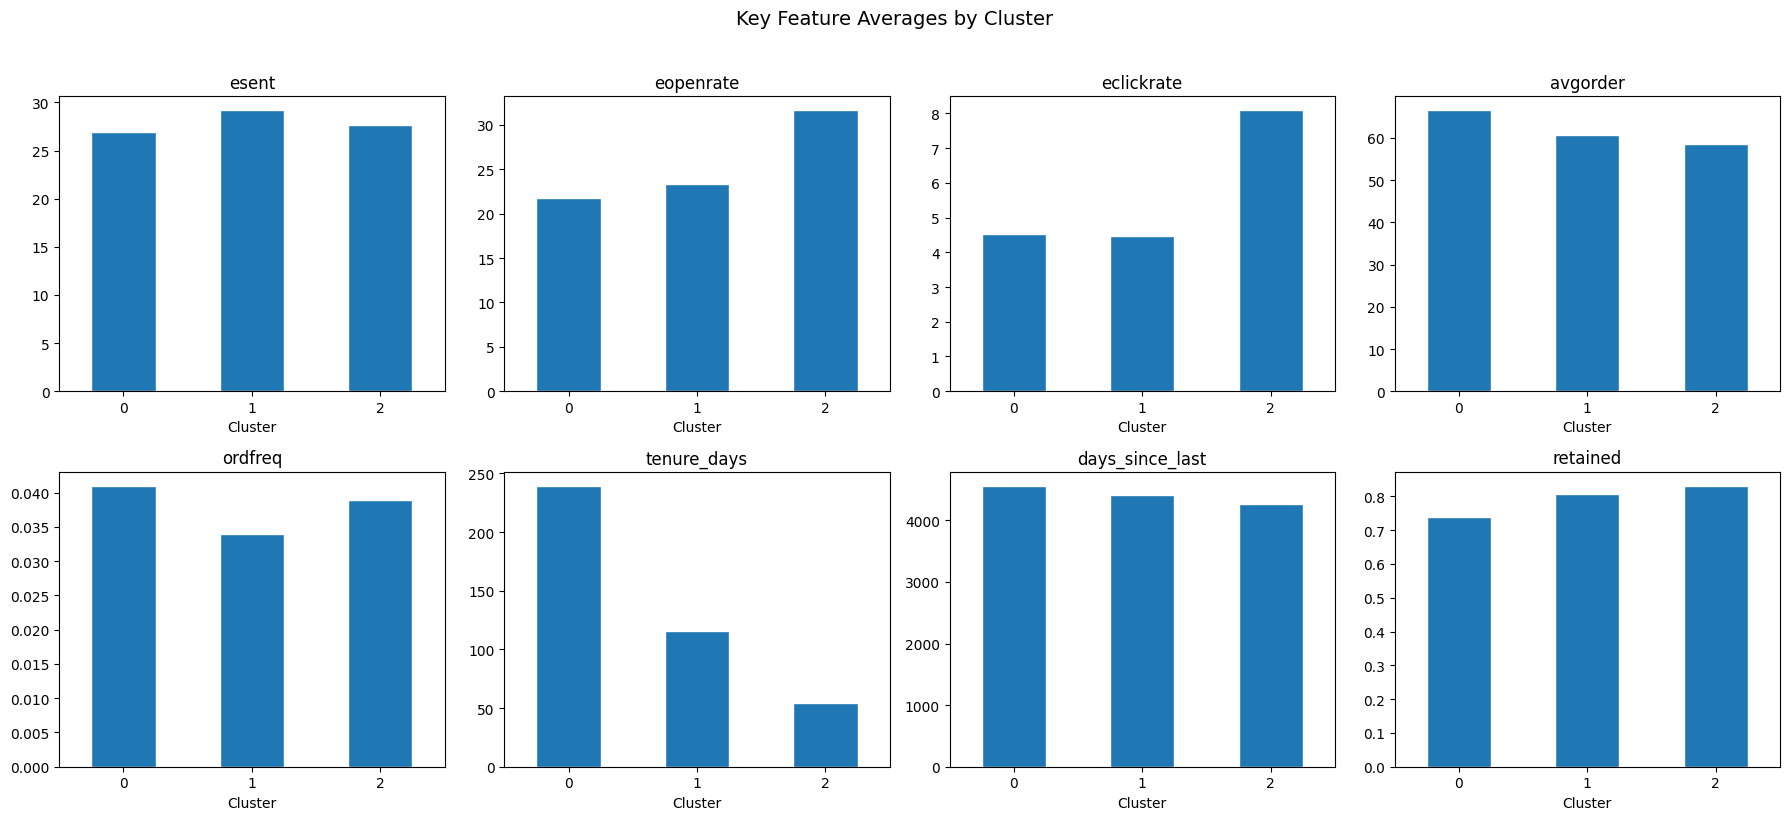

In [ ]:
# We will focus on the most business-relevant features
key_features = ['esent', 'eopenrate', 'eclickrate', 'avgorder', 'ordfreq',
                'tenure_days', 'days_since_last', 'retained']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    cluster_profile[feat].plot(kind='bar', ax=axes[i], edgecolor='white', colormap='tab10')
    axes[i].set_title(feat)
    axes[i].set_xlabel('Cluster')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)

plt.suptitle('Key Feature Averages by Cluster', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# The clusters seem primarily driven by city in this data set, with ssmall differences in tenure, email engagement, and spending behaviour
cluster_labels = {
    0: 'Veteran Low-Engagement Customers',
    1: 'Mid-Tenure Moderate Customers',
    2: 'New High-Engagement Customers'
}

train_clustered['cluster_name'] = train_clustered['cluster'].map(cluster_labels)

print('Cluster labels assigned:')
print(train_clustered['cluster_name'].value_counts())

Cluster labels assigned:
cluster_name
Mid-Tenure Moderate Customers       9827
New High-Engagement Customers       7741
Veteran Low-Engagement Customers    7038
Name: count, dtype: int64
